### Principal component analysis (PCA)

1. Load or create a dataset with more than 2 dimensions.
2. Find the first 2 principal components with and without using sklearn.
3. Practice using PCA to preserve a certain percentage of variance.
4. Train a classification or regression neural network by using: 
- a) The Original dataset
- b) Principal components

5. Repeat part 4 using Kernel PCA (linear, sigmoid, RBF).
6. Build a pipeline to tune the hyperparameters of Kernel PCA and also the neural network. Which
hyperparameters can be tuned?

2D means that the dataset has 2 or more featurs/colums per sample

In [13]:
# lets create some cluster blobs for a 2D dataset

from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X,y = make_blobs(n_samples=300, # number of points
                n_features=2,   # the dimension
                centers=4,      # number of cluster centers generated
                cluster_std=1.4,# the spread of the clusters
                random_state=42)# seed



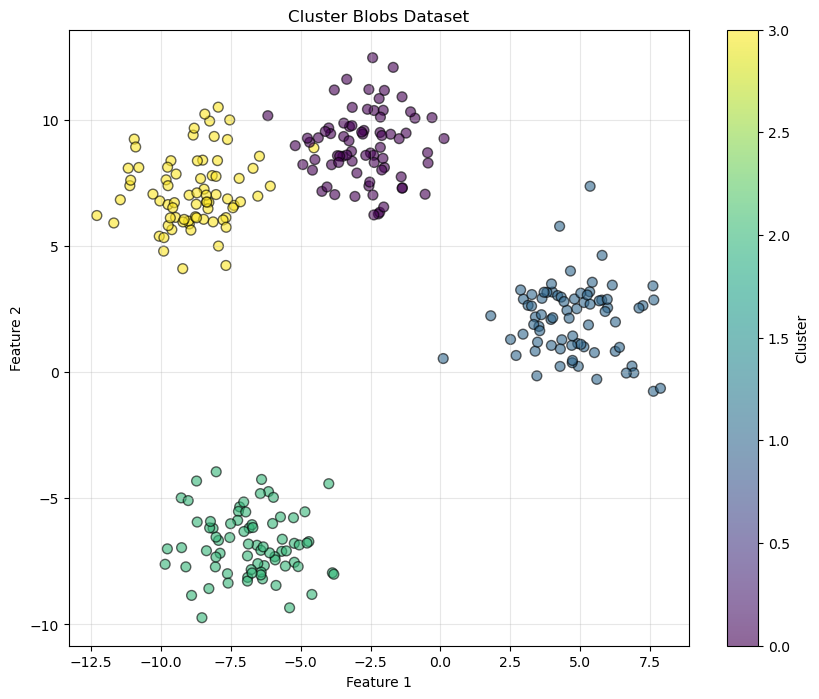

In [14]:
plt.figure(figsize=(10, 8))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=50, alpha=0.6, edgecolors='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Cluster Blobs Dataset')
plt.colorbar(label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
# PCA principa component analysis linear dimenson-reduction method
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X)
print(pca2.explained_variance_ratio_)
print("total variance",pca2.explained_variance_ratio_.sum())

pca95 = PCA(n_components=0.95) # preserve 95% of the data
X_pca95 = pca95.fit_transform(X)
print("asd",pca95.n_components_)
print("total variance",pca95.explained_variance_ratio_.sum())
print(f"seems like we find {pca95.n_components_} PCs becouse there only are {pca95.n_components_} ")
print("increaseing the amount of diemnsions to 5 will increase the amount of componetns to 3,\n but since we are only using 2 and finding 2 means that we are finding all the diemnsion \nof the data ")

[0.58117062 0.41882938]
total variance 1.0
asd 2
total variance 1.0
seems like we find 2 PCs becouse there only are 2 
increaseing the amount of diemnsions to 5 will increase the amount of componetns to 3,
 but since we are only using 2 and finding 2 means that we are finding all the diemnsion 
of the data 


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# split the data simillar to intro course
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# normalize it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# A ) train on the original dataset
model_OG = Sequential([
    Dense(16, activation='relu', input_dim=X_train_scaled.shape[1]),
    Dense(8,activation='relu'),
    Dense(4,activation='softmax'),
])
model_OG.compile(optimizer=Adam(learning_rate=0.001),
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])
hist_OG = model_OG.fit(X_train_scaled,y_train,epochs=50,batch_size=32,validation_split=0.2,verbose=2)




Epoch 1/50
6/6 - 0s - loss: 1.5205 - accuracy: 0.0000e+00 - val_loss: 1.4921 - val_accuracy: 0.0000e+00
Epoch 2/50
6/6 - 0s - loss: 1.4793 - accuracy: 0.0104 - val_loss: 1.4514 - val_accuracy: 0.0000e+00
Epoch 3/50
6/6 - 0s - loss: 1.4399 - accuracy: 0.1667 - val_loss: 1.4114 - val_accuracy: 0.2292
Epoch 4/50
6/6 - 0s - loss: 1.4019 - accuracy: 0.3125 - val_loss: 1.3724 - val_accuracy: 0.4583
Epoch 5/50
6/6 - 0s - loss: 1.3652 - accuracy: 0.3854 - val_loss: 1.3361 - val_accuracy: 0.5417
Epoch 6/50
6/6 - 0s - loss: 1.3310 - accuracy: 0.4531 - val_loss: 1.3029 - val_accuracy: 0.5625
Epoch 7/50
6/6 - 0s - loss: 1.2981 - accuracy: 0.5000 - val_loss: 1.2710 - val_accuracy: 0.5417
Epoch 8/50
6/6 - 0s - loss: 1.2660 - accuracy: 0.5208 - val_loss: 1.2401 - val_accuracy: 0.5208
Epoch 9/50
6/6 - 0s - loss: 1.2336 - accuracy: 0.5885 - val_loss: 1.2105 - val_accuracy: 0.5208
Epoch 10/50
6/6 - 0s - loss: 1.2021 - accuracy: 0.6302 - val_loss: 1.1822 - val_accuracy: 0.5625
Epoch 11/50
6/6 - 0s - loss

In [17]:
# B )

import numpy as np

# center data
X_train_centered = X_train - X_train.mean(axis=0)
X_test_centered = X_test - X_test.mean(axis=0)

# SVD on covariance (or directly on centered data)
U, S, Vt = np.linalg.svd(X_train_centered / np.sqrt(X_train_centered.shape[0]-1), full_matrices=False)

# columns of V = principal axes; S^2 = variances along PCs
explained_variance = S**2
explained_variance_ratio = explained_variance / explained_variance.sum()

# first 2 PCs and projections
components_2 = Vt[:2]


# .T betyder transpose
# @ means matrix multiplication since python 3.5
X_train_manual_PCA = X_train_centered @ components_2.T
X_test_manual_PCA = X_test_centered @ components_2.T


model_PCA = Sequential([
      Dense(16, activation='relu', input_dim=2),
    Dense(8,activation='relu'),
    Dense(4,activation='softmax'),
])

model_PCA.compile(optimizer=Adam(learning_rate=0.001),
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

hist_PCA = model_PCA.fit(X_train_manual_PCA,y_train,
                        epochs=50,
                        batch_size=32,
                        validation_split=.02,
                        verbose=2)

Epoch 1/50
8/8 - 0s - loss: 2.3215 - accuracy: 0.0000e+00 - val_loss: 1.9359 - val_accuracy: 0.0000e+00
Epoch 2/50
8/8 - 0s - loss: 2.0095 - accuracy: 0.0000e+00 - val_loss: 1.7028 - val_accuracy: 0.0000e+00
Epoch 3/50
8/8 - 0s - loss: 1.7567 - accuracy: 0.0000e+00 - val_loss: 1.5048 - val_accuracy: 0.0000e+00
Epoch 4/50
8/8 - 0s - loss: 1.5456 - accuracy: 0.0809 - val_loss: 1.3493 - val_accuracy: 0.4000
Epoch 5/50
8/8 - 0s - loss: 1.3778 - accuracy: 0.2553 - val_loss: 1.2273 - val_accuracy: 0.6000
Epoch 6/50
8/8 - 0s - loss: 1.2346 - accuracy: 0.3745 - val_loss: 1.1257 - val_accuracy: 0.6000
Epoch 7/50
8/8 - 0s - loss: 1.1096 - accuracy: 0.5574 - val_loss: 1.0423 - val_accuracy: 0.6000
Epoch 8/50
8/8 - 0s - loss: 0.9986 - accuracy: 0.7191 - val_loss: 0.9572 - val_accuracy: 0.8000
Epoch 9/50
8/8 - 0s - loss: 0.8987 - accuracy: 0.8383 - val_loss: 0.8790 - val_accuracy: 0.8000
Epoch 10/50
8/8 - 0s - loss: 0.8069 - accuracy: 0.9319 - val_loss: 0.8085 - val_accuracy: 0.8000
Epoch 11/50
8/8

example of usage of @ operator


In [18]:
import numpy as np
arr1 = np.array([1,1,1])
arr2 = np.array([2,2,2])
res = arr1 @ arr2
print(res)

6


In [19]:
print("Original accuracy:", model_OG.evaluate(X_test_scaled, y_test)[1])
print("PCA accuracy:", model_PCA.evaluate(X_test_manual_PCA, y_test)[1])


2/2 [==============================] - 0s 2ms/step - loss: 0.4257 - accuracy: 0.9833
Original accuracy: 0.9833333492279053
2/2 [==============================] - 0s 3ms/step - loss: 0.1211 - accuracy: 0.9667
PCA accuracy: 0.9666666388511658


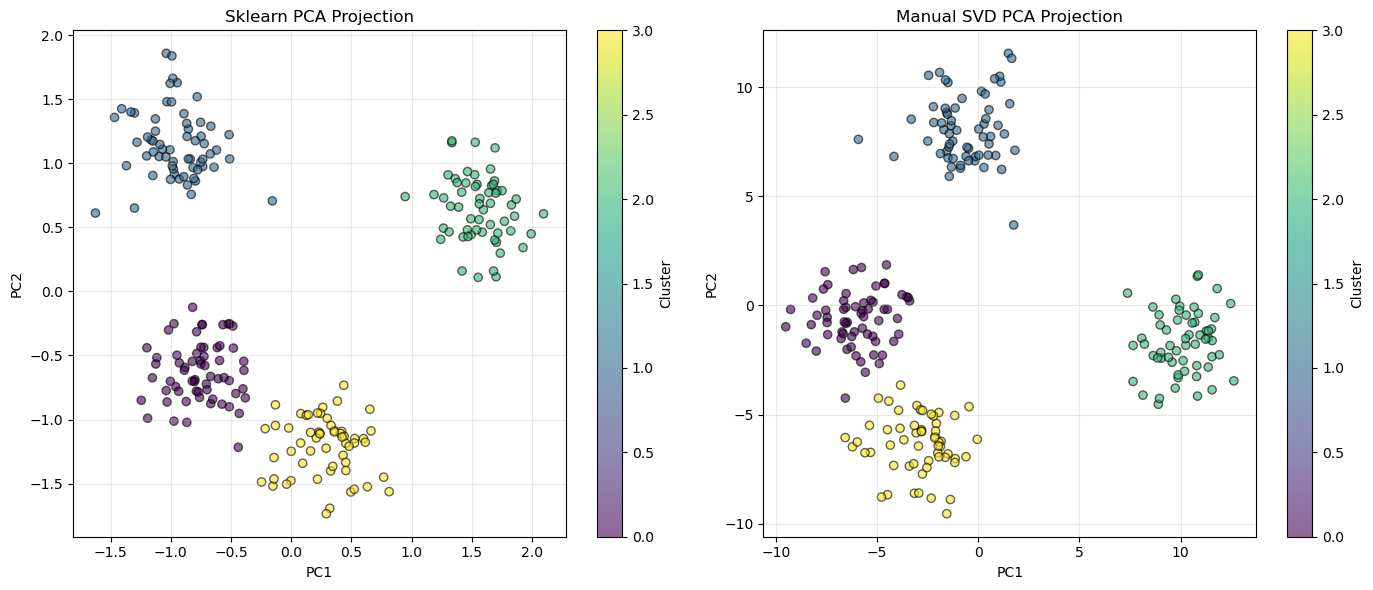

the manual and not give the same result,both have clusters that are seperable


In [20]:
plt.figure(figsize=(14, 6))

# Plot sklearn PCA (if you have it)
plt.subplot(1, 2, 1)
pca_sklearn = PCA(n_components=2)
X_train_sklearn_PCA = pca_sklearn.fit_transform(X_train_scaled)
plt.scatter(X_train_sklearn_PCA[:, 0], X_train_sklearn_PCA[:, 1], c=y_train, cmap='viridis', alpha=0.6, edgecolors='k')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Sklearn PCA Projection')
plt.colorbar(label='Cluster')
plt.grid(True, alpha=0.3)

# Plot manual PCA
plt.subplot(1, 2, 2)
plt.scatter(X_train_manual_PCA[:, 0], X_train_manual_PCA[:, 1], c=y_train, cmap='viridis', alpha=0.6, edgecolors='k')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Manual SVD PCA Projection')
plt.colorbar(label='Cluster')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("the manual and not give the same result,both have clusters that are seperable")

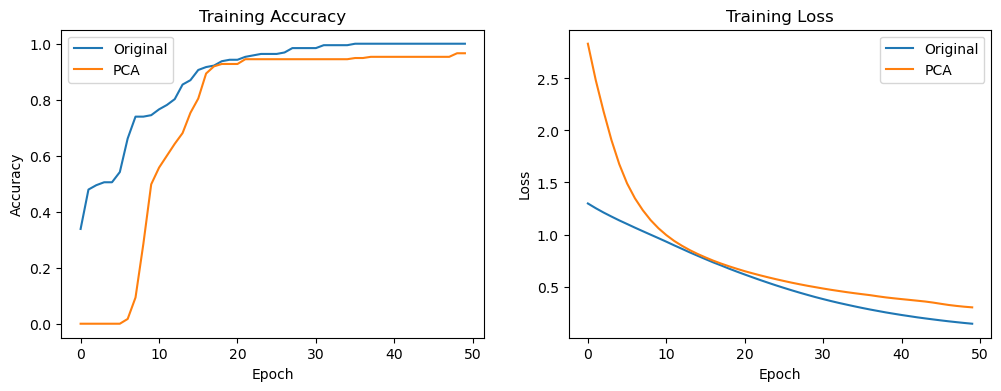

In [12]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(hist_OG.history['accuracy'], label='Original')
plt.plot(hist_PCA.history['accuracy'], label='PCA')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')

plt.subplot(1, 2, 2)
plt.plot(hist_OG.history['loss'], label='Original')
plt.plot(hist_PCA.history['loss'], label='PCA')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

Classification problem
1. Load IRIS and MNIST fashion datasets from Keras.
2. Build and train a neural network for classifying the loaded labeled datasets.
3. Tune the hyperparameters (including hidden layer size and activation functions). What else can be tuned?
4. Plot the loss and accuracy for training and testing datasets.
5. Save the weights of the layers and use callbacks during the training process.
6. Practice saving and loading the trained model.

In [ ]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint




In [15]:
(x_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

In [16]:
gray_scale = 255
x_train = x_train.astype('float32') / gray_scale
X_test = X_test.astype('float32') / gray_scale

print("Feature matrix (x_train):", x_train.shape)
print("Target matrix (y_train):", y_train.shape)
print("Feature matrix (x_test):", X_test.shape)
print("Target matrix (y_test):", y_test.shape)

Feature matrix (x_train): (60000, 28, 28)
Target matrix (y_train): (60000,)
Feature matrix (x_test): (10000, 28, 28)
Target matrix (y_test): (10000,)


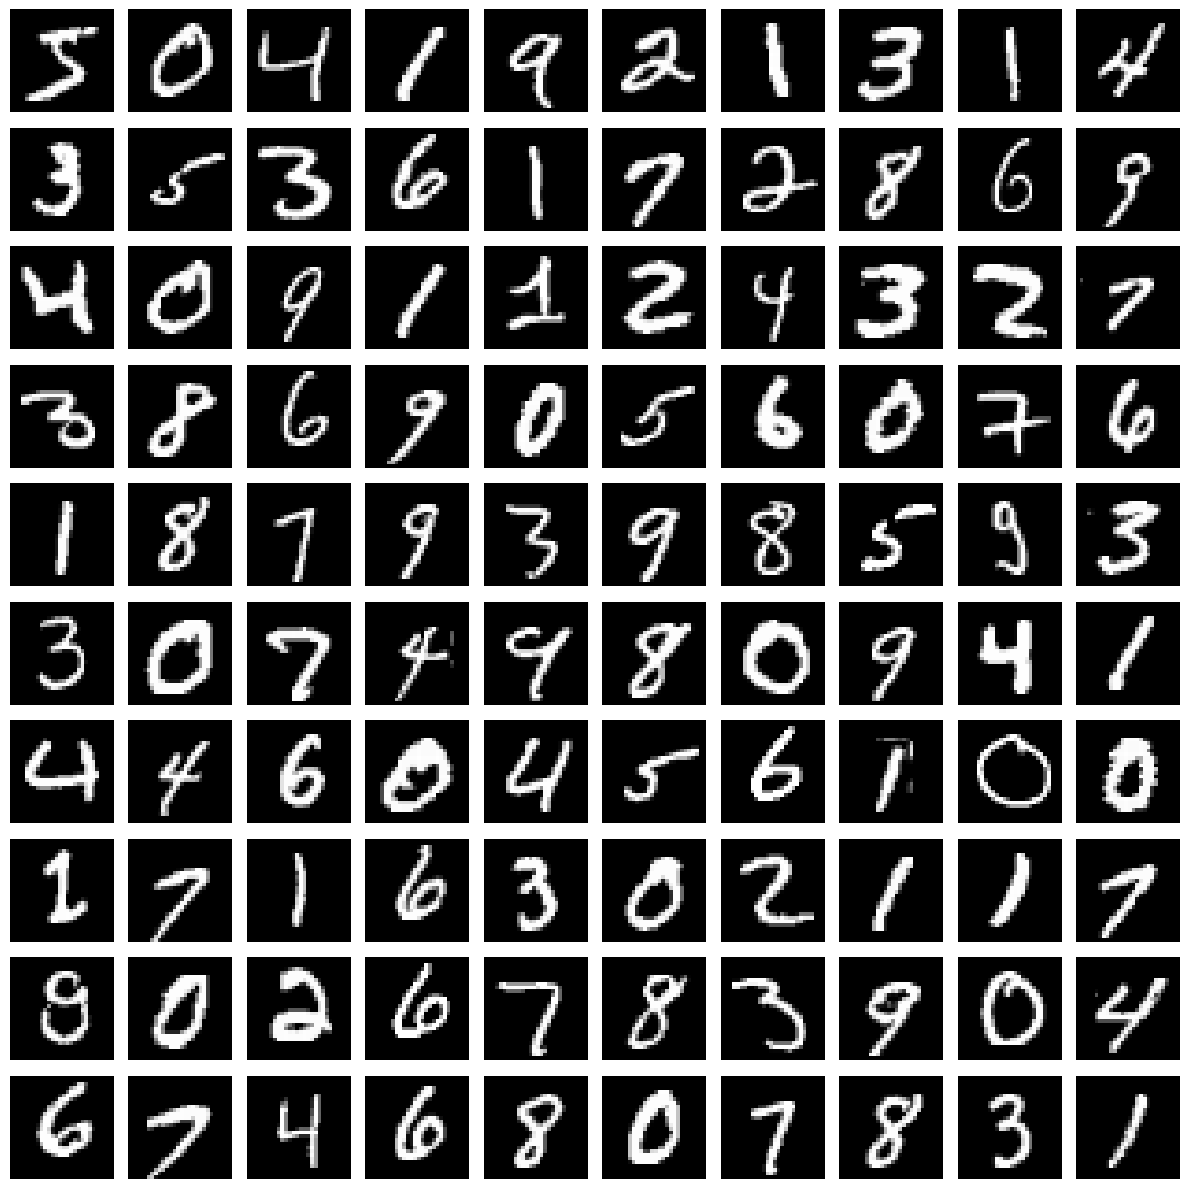

In [17]:

fig, ax = plt.subplots(10, 10, figsize=(12, 12))
k = 0
for i in range(10):
    for j in range(10):
        ax[i][j].imshow(x_train[k], cmap='gray')
        ax[i][j].axis('off')
        k += 1
plt.tight_layout()
plt.show()

In [18]:
Tuning = [
    {'hidden1':128,'hidden2':64,'activation':'relu','learning_rate':0.001 },
    {'hidden1':256,'hidden2':128,'activation':'sigmoid','learning_rate':0.0005 },
    {'hidden1':512,'hidden2':256,'activation':'tanh','learning_rate':0.0001 },
]

In [19]:
results = []
for Tunes in Tuning:
    model = Sequential([
        Flatten(input_shape=(28,28)),
        Dense(Tunes['hidden1'],activation=Tunes['activation']),
        Dense(Tunes['hidden2'],activation=Tunes['activation']),
        Dense(10,activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=Tunes['learning_rate']),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    train_model = model.fit(x_train,y_train,
                            epochs=10,
                            validation_split=.2,
                            verbose=2)
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    results.append({
        'Tunes': Tunes,
        'test_accuracy': test_acc,
        'test_loss': test_loss
    })

    print(f"Config: {Tunes} → Accuracy: {test_acc:.4f}")
# Compare what setup was the best
best = max(results, key=lambda x: x['test_accuracy'])
print(f"\nBest configuration: {best['Tunes']}")
print(f"Best accuracy: {best['test_accuracy']:.4f}")

Epoch 1/10
1500/1500 - 1s - loss: 0.2689 - accuracy: 0.9224 - val_loss: 0.1453 - val_accuracy: 0.9584
Epoch 2/10
1500/1500 - 1s - loss: 0.1166 - accuracy: 0.9648 - val_loss: 0.1110 - val_accuracy: 0.9664
Epoch 3/10
1500/1500 - 1s - loss: 0.0816 - accuracy: 0.9754 - val_loss: 0.1054 - val_accuracy: 0.9693
Epoch 4/10
1500/1500 - 1s - loss: 0.0588 - accuracy: 0.9817 - val_loss: 0.0937 - val_accuracy: 0.9712
Epoch 5/10
1500/1500 - 1s - loss: 0.0465 - accuracy: 0.9851 - val_loss: 0.0978 - val_accuracy: 0.9732
Epoch 6/10
1500/1500 - 1s - loss: 0.0373 - accuracy: 0.9877 - val_loss: 0.1054 - val_accuracy: 0.9722
Epoch 7/10
1500/1500 - 1s - loss: 0.0312 - accuracy: 0.9893 - val_loss: 0.1036 - val_accuracy: 0.9743
Epoch 8/10
1500/1500 - 1s - loss: 0.0265 - accuracy: 0.9908 - val_loss: 0.1287 - val_accuracy: 0.9689
Epoch 9/10
1500/1500 - 1s - loss: 0.0223 - accuracy: 0.9926 - val_loss: 0.1033 - val_accuracy: 0.9753
Epoch 10/10
1500/1500 - 1s - loss: 0.0172 - accuracy: 0.9941 - val_loss: 0.1194 - 

- EarlyStopping: Stops training if validation loss doesn't improve for 3 epochs
- ModelCheckpoint: Saves the best model during training
- Best hyperparameters: 128→64 neurons, relu activation, learning rate 0.001

In [20]:
# build the NN

model = Sequential([
    Flatten(input_shape=(28,28)),# reshape 2D input into a 28x28 pixels = 784 components
    Dense(128,activation='relu'), # connect the layers with 128 and 64 neruons
    Dense(64,activation='relu'),
    Dense(10,activation='softmax'), # final layer with 10 neruons representing 10 classes of the digits 0-9

])

# compile model with the better learning rate
model.compile(optimizer=Adam(learning_rate=0.001),
            loss = 'sparse_categorical_crossentropy',
            metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss',
                        patience=3,
                        restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model.h5',
                            monitor='val_accuracy',
                            save_best_only=True)

# train model
train_model = model.fit(x_train, y_train,
                        epochs=50,
                        batch_size=32,
                        validation_split=0.2,
                        callbacks=[early_stop, checkpoint],
                        verbose=1)

# Evaluate
results = model.evaluate(X_test, y_test, verbose=0)
print('Test loss, Test accuracy:', results)

# Save final model and weights
model.save_weights('mnist_weights.h5')
model.save('mnist_model.h5')

Epoch 1/50
1500/1500 [==============================] - 1s 605us/step - loss: 0.2649 - accuracy: 0.9222 - val_loss: 0.1328 - val_accuracy: 0.9610
Epoch 2/50
1500/1500 [==============================] - 1s 637us/step - loss: 0.1124 - accuracy: 0.9659 - val_loss: 0.1154 - val_accuracy: 0.9650
Epoch 3/50
1500/1500 [==============================] - 1s 621us/step - loss: 0.0757 - accuracy: 0.9767 - val_loss: 0.1000 - val_accuracy: 0.9713
Epoch 4/50
1500/1500 [==============================] - 1s 672us/step - loss: 0.0595 - accuracy: 0.9813 - val_loss: 0.0960 - val_accuracy: 0.9732
Epoch 5/50
1500/1500 [==============================] - 1s 686us/step - loss: 0.0471 - accuracy: 0.9852 - val_loss: 0.0942 - val_accuracy: 0.9744
Epoch 6/50
1500/1500 [==============================] - 1s 613us/step - loss: 0.0350 - accuracy: 0.9888 - val_loss: 0.0936 - val_accuracy: 0.9746
Epoch 7/50
1500/1500 [==============================] - 1s 638us/step - loss: 0.0300 - accuracy: 0.9900 - val_loss: 0.1123 -

In [21]:
results = model.evaluate(X_test, y_test, verbose=0)
print('Test loss, Test accuracy:', results)

Test loss, Test accuracy: [0.08980704843997955, 0.9771000146865845]


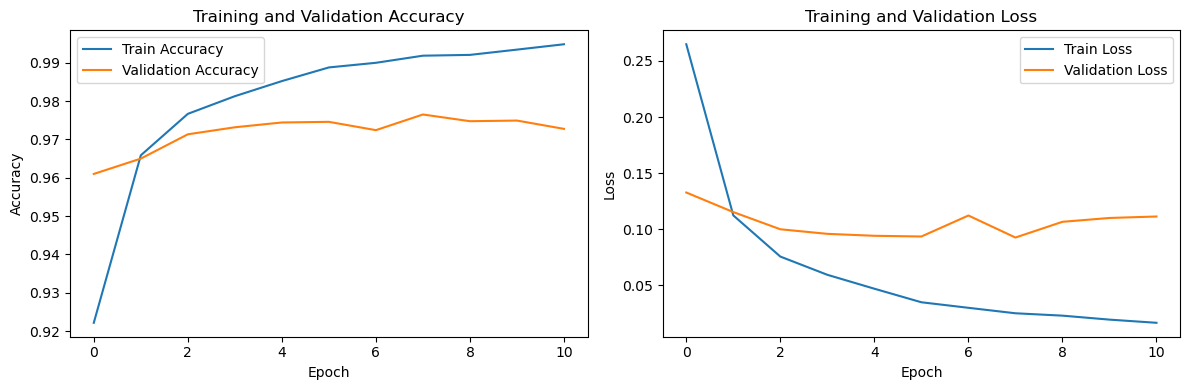

In [22]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_model.history['accuracy'], label='Train Accuracy')
plt.plot(train_model.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(train_model.history['loss'], label='Train Loss')
plt.plot(train_model.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.tight_layout()
plt.show()

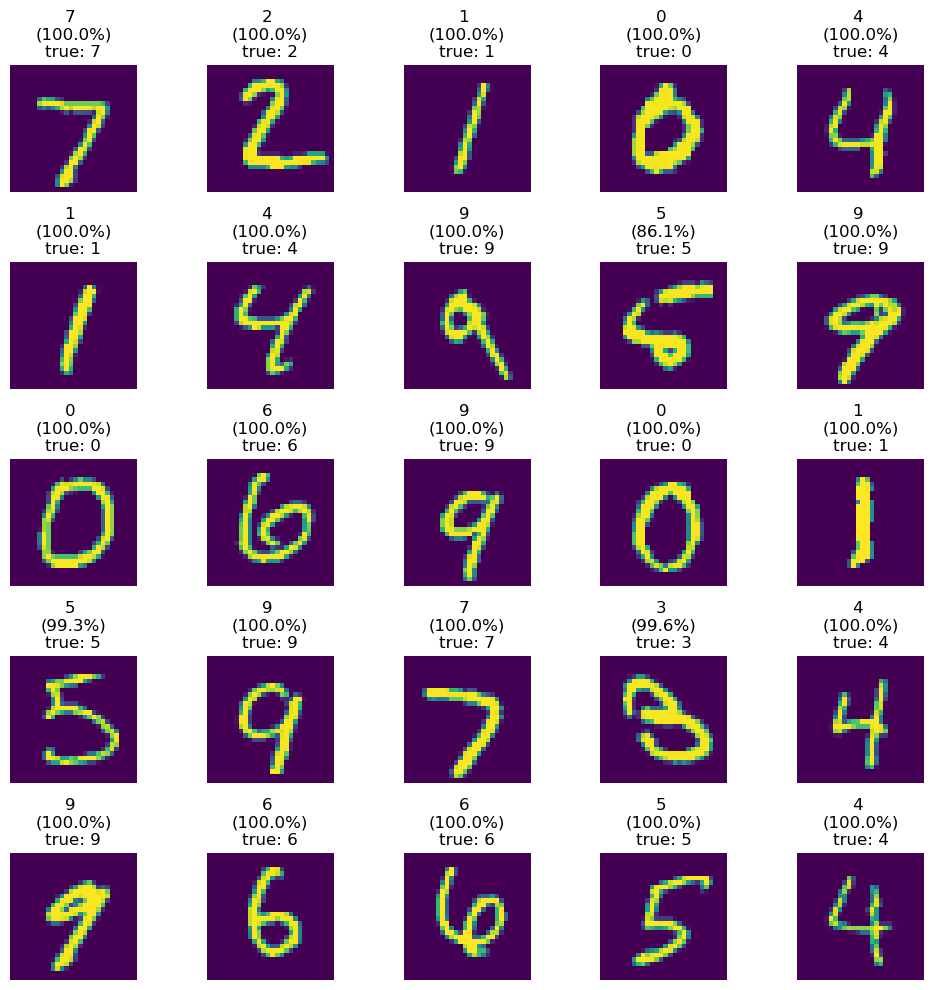

In [26]:
import numpy as np
class_names = ['0','1','2','3','4','5','6','7','8','9']

probs = model.predict(X_test[:25])
preds = np.argmax(probs,axis=-1)
confs = probs.max(axis=-1)

fig, axes = plt.subplots(5,5, figsize=(10,10))
for ax, img, p, c, t in zip(axes.ravel(), X_test[:25], preds, confs, y_test[:25]):
    pred_name = class_names[int(p)]
    true_name = class_names[int(t)]
    ax.imshow(img)
    ax.set_title(f"{pred_name} \n({c*100:.1f}%)\ntrue: {true_name}")
    ax.axis('off')
plt.tight_layout()
plt.show()



Sick 100% on almost all 

Iris 

In [5]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X_iris = iris.data  # Features (150 samples, 4 features)
y_iris = iris.target  # Labels (0, 1, 2 for the three iris species)

In [6]:
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42
)

In [7]:
scaler_iris = StandardScaler()
X_train_iris = scaler_iris.fit_transform(X_train_iris)
X_test_iris = scaler_iris.transform(X_test_iris)

In [ ]:
# 2 & 3) Hyperparameter tuning for Iris
iris_configs = [
    # hidden1: neurons in 1st hidden layer, hidden2: neurons in 2nd hidden layer
    # activation: relu/sigmoid/tanh, learning_rate: optimizer step size
    {'hidden1': 32, 'hidden2': 16, 'activation': 'relu', 'learning_rate': 0.001},
    {'hidden1': 64, 'hidden2': 32, 'activation': 'relu', 'learning_rate': 0.001},
    {'hidden1': 64, 'hidden2': 32, 'activation': 'sigmoid', 'learning_rate': 0.0005},
    {'hidden1': 128, 'hidden2': 64, 'activation': 'tanh', 'learning_rate': 0.0001},
]

iris_results = []
for config in iris_configs:
    model = Sequential([
        Dense(config['hidden1'], activation=config['activation'], input_shape=(4,)),
        Dense(config['hidden2'], activation=config['activation']),
        Dense(3, activation='softmax')  # 3 classes
    ])

    model.compile(optimizer=Adam(learning_rate=config['learning_rate']),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    hist = model.fit(X_train_iris, y_train_iris,
                     epochs=50,
                     batch_size=8,
                     validation_split=0.2,
                     verbose=0)

    test_loss, test_acc = model.evaluate(X_test_iris, y_test_iris, verbose=0)
    iris_results.append({'config': config, 'test_accuracy': test_acc, 'test_loss': test_loss})
    print(f"Config {config} → Accuracy: {test_acc:.4f}")

best_iris_config = max(iris_results, key=lambda x: x['test_accuracy'])
print(f"\nBest Iris config: {best_iris_config['config']}")
print(f"Best Iris accuracy: {best_iris_config['test_accuracy']:.4f}")

Config {'hidden1': 32, 'hidden2': 16, 'activation': 'relu', 'learning_rate': 0.001} → Accuracy: 1.0000
Config {'hidden1': 64, 'hidden2': 32, 'activation': 'relu', 'learning_rate': 0.001} → Accuracy: 0.9667
Config {'hidden1': 64, 'hidden2': 32, 'activation': 'sigmoid', 'learning_rate': 0.0005} → Accuracy: 0.9000
Config {'hidden1': 128, 'hidden2': 64, 'activation': 'tanh', 'learning_rate': 0.0001} → Accuracy: 0.9667

Best Iris config: {'hidden1': 32, 'hidden2': 16, 'activation': 'relu', 'learning_rate': 0.001}
Best Iris accuracy: 1.0000


In [ ]:
# Build and train best Iris model with callbacks
iris_model = Sequential([
    Dense(best_iris_config['config']['hidden1'],
          activation=best_iris_config['config']['activation'],
          input_shape=(4,)),
    Dense(best_iris_config['config']['hidden2'],
          activation=best_iris_config['config']['activation']),
    Dense(3, activation='softmax')
])

iris_model.compile(optimizer=Adam(learning_rate=best_iris_config['config']['learning_rate']),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

# 5) Callbacks
iris_early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
iris_checkpoint = ModelCheckpoint('best_iris_model.h5', monitor='val_accuracy', save_best_only=True)

# Train
iris_history = iris_model.fit(X_train_iris, y_train_iris,
                              epochs=100,
                              batch_size=8,
                              validation_split=0.2,
                              callbacks=[iris_early_stop, iris_checkpoint],
                              verbose=1)

# Evaluate
iris_test_loss, iris_test_acc = iris_model.evaluate(X_test_iris, y_test_iris, verbose=0)
print(f'Iris Test Loss: {iris_test_loss:.4f}, Test Accuracy: {iris_test_acc:.4f}')

# 5) Save weights and model
iris_model.save_weights('iris_weights.h5')
iris_model.save('iris_model.h5')

Epoch 1/100
12/12 [==============================] - 1s 49ms/step - loss: 1.1096 - accuracy: 0.4688 - val_loss: 1.2002 - val_accuracy: 0.4583
Epoch 2/100
12/12 [==============================] - 0s 3ms/step - loss: 1.0052 - accuracy: 0.6042 - val_loss: 1.1147 - val_accuracy: 0.4583
Epoch 3/100
12/12 [==============================] - 0s 3ms/step - loss: 0.9257 - accuracy: 0.6250 - val_loss: 1.0460 - val_accuracy: 0.4583
Epoch 4/100
12/12 [==============================] - 0s 3ms/step - loss: 0.8553 - accuracy: 0.6354 - val_loss: 0.9800 - val_accuracy: 0.4583
Epoch 5/100
12/12 [==============================] - 0s 2ms/step - loss: 0.7924 - accuracy: 0.6562 - val_loss: 0.9210 - val_accuracy: 0.4583
Epoch 6/100
12/12 [==============================] - 0s 5ms/step - loss: 0.7370 - accuracy: 0.7188 - val_loss: 0.8702 - val_accuracy: 0.6250
Epoch 7/100
12/12 [==============================] - 0s 3ms/step - loss: 0.6899 - accuracy: 0.7708 - val_loss: 0.8281 - val_accuracy: 0.6250
Epoch 8/100


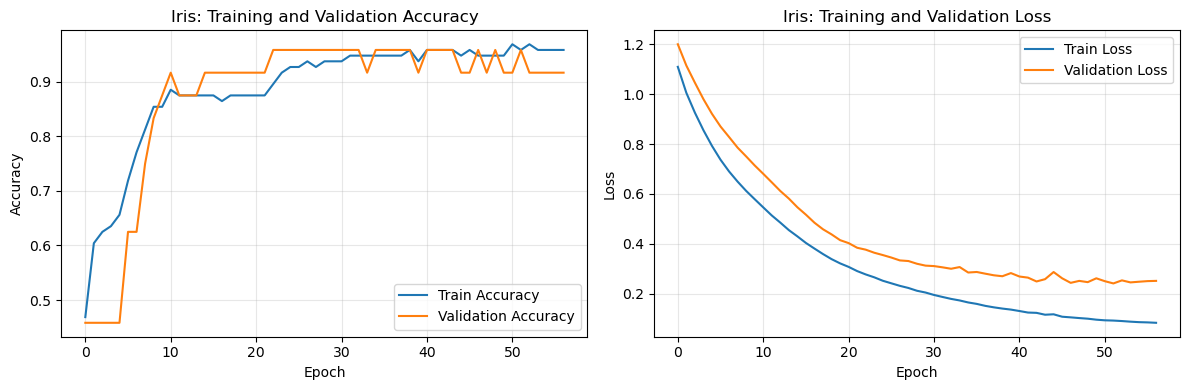

In [12]:
# 4) Plot loss and accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(iris_history.history['accuracy'], label='Train Accuracy')
plt.plot(iris_history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Iris: Training and Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(iris_history.history['loss'], label='Train Loss')
plt.plot(iris_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Iris: Training and Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# 6) Load and test the saved model
loaded_iris_model = tf.keras.models.load_model('iris_model.h5')
loaded_iris_loss, loaded_iris_acc = loaded_iris_model.evaluate(X_test_iris, y_test_iris, verbose=0)
print(f'Loaded Iris Model - Loss: {loaded_iris_loss:.4f}, Accuracy: {loaded_iris_acc:.4f}')

# Make predictions
iris_predictions = loaded_iris_model.predict(X_test_iris)
iris_pred_classes = np.argmax(iris_predictions, axis=1)

# Show some predictions
print("\nSample predictions:")
for i in range(10):
    print(f"True: {y_test_iris[i]}, Predicted: {iris_pred_classes[i]}, Confidence: {iris_predictions[i].max():.2%}")

Loaded Iris Model - Loss: 0.0873, Accuracy: 0.3333

Sample predictions:
True: 1, Predicted: 1, Confidence: 93.13%
True: 0, Predicted: 0, Confidence: 99.75%
True: 2, Predicted: 2, Confidence: 99.81%
True: 1, Predicted: 1, Confidence: 79.94%
True: 1, Predicted: 1, Confidence: 85.51%
True: 0, Predicted: 0, Confidence: 99.70%
True: 1, Predicted: 1, Confidence: 96.65%
True: 2, Predicted: 2, Confidence: 97.80%
True: 1, Predicted: 2, Confidence: 60.29%
True: 1, Predicted: 1, Confidence: 97.41%


Regression problem
1. Load California housing dataset and split it to training and testing datasets.
2. Build and train a neural network for price prediction. Tune the hyperparameters and discuss the results.
3. Plot the network history.
4. Change the learning rate. Train the network again and plot the network history. Discuss the results.
5. Save the weights of the layers and use callbacks during the training process.
6. Practice saving and loading the trained model.

In [3]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint
import matplotlib.pyplot as plt
import tensorflow as tf


In [4]:
# fetch data and split it into training and test

house_data = fetch_california_housing()
X,y = house_data.data, house_data.target

X_train, X_test, y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)


In [ ]:
#standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# hyperparameter tuning for a simple grid

tuning = [
    {'hidden1':64,'hidden2':32,'activation':'relu','lr':1e-3},
    {'hidden1':128,'hidden2':64,'activation':'relu','lr':1e-3},
    {'hidden1':256,'hidden2':128,'activation':'tanh','lr':5e-3},

]

In [7]:
def build_model(h1,h2,act,lr):
    model = Sequential([
        Dense(h1,activation=act,input_shape=(X_train.shape[1],)),
        Dense(h2,activation=act),
        Dense(1),
    ])

    model.compile(optimizer=Adam(learning_rate=lr),
                loss='mse',
                metrics=['mae']
                )
    return model

res = []
for cfg in tuning:
    model = build_model(cfg["hidden1"], cfg["hidden2"], cfg["activation"], cfg["lr"])
    hist = model.fit(
        X_train, y_train,
        epochs=60,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )
    test_loss, test_mae = model.evaluate(X_test,y_test, verbose=0)
    res.append((cfg,test_mae))
    print(f"config {cfg}: test MAE: {test_mae:.3f}")

best_cfg = sorted(res,key=lambda x: x[1])[0][0]
print(f'best config: {best_cfg}')



config {'hidden1': 64, 'hidden2': 32, 'activation': 'relu', 'lr': 0.001}: test MAE: 0.360
config {'hidden1': 128, 'hidden2': 64, 'activation': 'relu', 'lr': 0.001}: test MAE: 0.367
config {'hidden1': 256, 'hidden2': 128, 'activation': 'tanh', 'lr': 0.005}: test MAE: 0.346
best config: {'hidden1': 256, 'hidden2': 128, 'activation': 'tanh', 'lr': 0.005}


In [8]:
# train the best model and callback with eraly stop

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint("best_reg_model.h5", monitor="val_loss", save_best_only=True)

best_model = build_model(best_cfg["hidden1"], best_cfg["hidden2"], best_cfg["activation"], best_cfg["lr"])
history = best_model.fit(
    X_train, y_train,
    epochs=100, batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/100
413/413 [==============================] - 1s 2ms/step - loss: 0.6030 - mae: 0.5538 - val_loss: 0.4985 - val_mae: 0.5150
Epoch 2/100
413/413 [==============================] - 1s 2ms/step - loss: 0.4202 - mae: 0.4671 - val_loss: 0.4495 - val_mae: 0.5082
Epoch 3/100
413/413 [==============================] - 1s 1ms/step - loss: 0.3603 - mae: 0.4253 - val_loss: 0.3786 - val_mae: 0.4258
Epoch 4/100
413/413 [==============================] - 0s 1ms/step - loss: 0.3485 - mae: 0.4175 - val_loss: 0.3594 - val_mae: 0.4105
Epoch 5/100
413/413 [==============================] - 0s 1ms/step - loss: 0.3430 - mae: 0.4138 - val_loss: 0.3510 - val_mae: 0.4191
Epoch 6/100
413/413 [==============================] - 0s 1ms/step - loss: 0.3391 - mae: 0.4091 - val_loss: 0.3701 - val_mae: 0.4176
Epoch 7/100
413/413 [==============================] - 0s 1ms/step - loss: 0.3300 - mae: 0.4031 - val_loss: 0.3648 - val_mae: 0.4252
Epoch 8/100
413/413 [==============================] - 0s 1ms/step - 

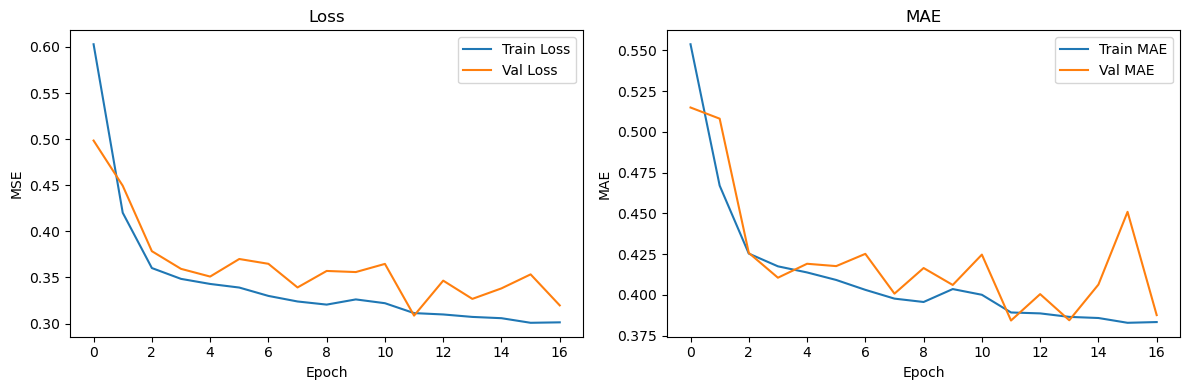

Epoch 1/100
413/413 - 0s - loss: 2.1358 - mae: 1.1408 - val_loss: 0.5279 - val_mae: 0.5154
Epoch 2/100
413/413 - 0s - loss: 0.4798 - mae: 0.5035 - val_loss: 0.5125 - val_mae: 0.5133
Epoch 3/100
413/413 - 0s - loss: 0.4707 - mae: 0.5011 - val_loss: 0.5049 - val_mae: 0.5186
Epoch 4/100
413/413 - 0s - loss: 0.4667 - mae: 0.4996 - val_loss: 0.5000 - val_mae: 0.5120
Epoch 5/100
413/413 - 0s - loss: 0.4647 - mae: 0.4989 - val_loss: 0.4941 - val_mae: 0.5114
Epoch 6/100
413/413 - 0s - loss: 0.4601 - mae: 0.4960 - val_loss: 0.4935 - val_mae: 0.5106
Epoch 7/100
413/413 - 0s - loss: 0.4583 - mae: 0.4946 - val_loss: 0.4884 - val_mae: 0.5080
Epoch 8/100
413/413 - 0s - loss: 0.4558 - mae: 0.4932 - val_loss: 0.4906 - val_mae: 0.5079
Epoch 9/100
413/413 - 0s - loss: 0.4527 - mae: 0.4929 - val_loss: 0.4898 - val_mae: 0.5134
Epoch 10/100
413/413 - 0s - loss: 0.4510 - mae: 0.4900 - val_loss: 0.4865 - val_mae: 0.5085
Epoch 11/100
413/413 - 0s - loss: 0.4505 - mae: 0.4907 - val_loss: 0.4783 - val_mae: 0.50

In [14]:
# 3) Plot history (loss/MAE)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.title("Loss"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["mae"], label="Train MAE")
plt.plot(history.history["val_mae"], label="Val MAE")
plt.xlabel("Epoch"); plt.ylabel("MAE"); plt.title("MAE"); plt.legend()
plt.tight_layout(); plt.show()

# 4) Change learning rate and retrain
new_lr = 1e-4
model_lr = build_model(best_cfg["hidden1"], best_cfg["hidden2"], best_cfg["activation"], new_lr)
history_lr = model_lr.fit(
    X_train, y_train,
    epochs=100, batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=2
)




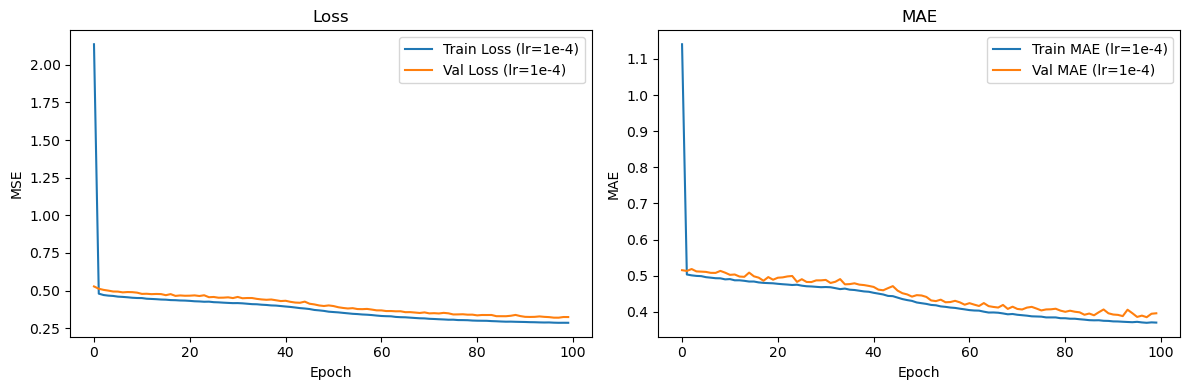

In [17]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_lr.history["loss"], label="Train Loss (lr=1e-4)")
plt.plot(history_lr.history["val_loss"], label="Val Loss (lr=1e-4)")
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.title("Loss"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_lr.history["mae"], label="Train MAE (lr=1e-4)")
plt.plot(history_lr.history["val_mae"], label="Val MAE (lr=1e-4)")
plt.xlabel("Epoch"); plt.ylabel("MAE"); plt.title("MAE"); plt.legend()
plt.tight_layout(); plt.show()

In [18]:

# 5) Save weights + use callbacks already above
best_model.save_weights("regression_weights.h5")

# 6) Save and load full model
best_model.save("regression_model.h5")
loaded_model = tf.keras.models.load_model("regression_model.h5")
loaded_eval = loaded_model.evaluate(X_test, y_test, verbose=0)
print("Loaded model (MSE, MAE):", loaded_eval)

Loaded model (MSE, MAE): [0.3030848205089569, 0.37700366973876953]
